## Data Understanding

In [1]:
#!uv pip install openpyxl

In [2]:
# Importing the necessary libararies
import os
import sys
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Get the absolute path of the directory one level up (project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add it to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# import SoilDataPreprocessor
from api.utils.preprocessing import SoilDataPreprocessor

In [4]:
sns.set_style('darkgrid')

In [5]:
# read data from the cleaned sheet
df_clean = pd.read_excel('../data/cleaned.xlsx', sheet_name='Sheet1')

# preview of the first 10 rows of the dataframe
df_clean.head(10)

,Simplied Texture (1),pH,N,P,K,O,Ca,Mg,Cu,Fe,Zn,Soil Fertility Status,Crop Recommendation 1,Crop Recommendation 2,Fertilizer Recommendation 1,Fertilizer Recommendation 2
0,SILTY SOIL,4.9,0.14,22.9,0.14,1.1,1.3,2.2,1.2,10.1,5.6,VERY POOR,CASSAVA,COTTON,NPK,NPK
1,LOAMY SOIL,5.7,0.14,28.3,0.27,1.3,1.8,2.1,1.2,12.9,5.2,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
2,SILTY LOAM,5.9,0.16,23.1,0.39,2.1,1.6,2.5,1.2,10.1,6.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
3,LOAMY SOIL,5.7,0.20,29.2,0.47,2.1,2.8,2.2,1.2,12.0,7.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
4,LOAM,5.7,0.14,28.3,0.28,2.2,3.2,1.4,1.2,12.3,7.0,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
5,SILTY SAND,5.7,0.17,29.2,0.72,2.0,2.4,1.9,1.2,11.2,10.3,MODERATELY HEALTHY,SOYBEAN,SESAME,NPK,NPK
6,SILT,5.9,0.18,27.2,0.18,1.9,2.7,2.0,1.4,13.1,5.9,MODERATELY HEALTHY,BEANS,MAIZE,NPK,TSP
7,LOAM,5.7,0.16,22.9,1.22,1.2,2.2,1.5,1.7,12.4,9.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
8,LOAMY SILT,5.6,0.15,19.4,0.72,1.3,1.9,2.2,1.2,12.6,8.7,POOR,BANANA,ALVS,NPK,NPK
9,LOAM,5.4,0.14,23.2,1.21,1.4,1.1,2.1,1.1,12.9,6.8,POOR,MAIZE,BEANS,NPK,TSP


In [6]:
# sample the dataset 
df_clean.sample(10)

,Simplied Texture (1),pH,N,P,K,O,Ca,Mg,Cu,Fe,Zn,Soil Fertility Status,Crop Recommendation 1,Crop Recommendation 2,Fertilizer Recommendation 1,Fertilizer Recommendation 2
911,LOAMY SOIL,5.1,0.14,19.8,0.39,2.2,1.2,2.5,1.2,10.1,3.9,POOR,COTTON,CASSAVA,NPK,NPK
207,LOAM,5.2,0.17,22.9,1.07,1.0,1.0,1.2,1.5,12.6,9.4,POOR,SESAME,SOYBEAN,NPK,NPK
953,LOAMY SOIL,5.5,0.14,19.8,1.17,0.5,1.9,1.1,1.5,12.2,10.3,POOR,SESAME,SOYBEAN,NPK,NPK
27,SILTY SAND,6.4,0.23,22.9,1.07,1.8,5.2,1.1,1.5,12.2,5.6,MODERATELY HEALTHY,MILLET,SORGHUM,NPK,NPK
428,LOAMY SOIL,6.1,0.24,19.4,1.21,1.5,1.1,2.1,1.1,12.9,7.4,MODERATELY HEALTHY,ALVS,BANANA,NPK,NPK
93,LOAM,5.8,0.19,23.9,1.07,0.9,8.2,1.7,1.5,11.2,4.8,MODERATELY HEALTHY,SUNFLOWER,MILLET,NPK,NPK
974,LOAMY SOIL,5.3,0.14,29.2,1.07,1.4,1.8,2.2,1.5,12.2,5.6,POOR,COTTON,CASSAVA,NPK,NPK
733,LOAMY SOIL,5.1,0.15,26.3,1.07,1.1,2.9,1.8,1.4,11.2,4.4,POOR,SOYBEAN,SESAME,NPK,NPK
630,SILTY SOIL,5.4,0.14,19.8,1.07,1.9,2.4,2.2,1.7,12.1,3.9,POOR,SESAME,SOYBEAN,NPK,NPK
353,LOAMY SOIL,5.1,0.15,28.3,1.07,1.2,3.3,1.1,1.5,10.9,7.4,POOR,SESAME,SOYBEAN,NPK,NPK


In [7]:
# Preview of the tail data
df_clean.tail(10)

,Simplied Texture (1),pH,N,P,K,O,Ca,Mg,Cu,Fe,Zn,Soil Fertility Status,Crop Recommendation 1,Crop Recommendation 2,Fertilizer Recommendation 1,Fertilizer Recommendation 2
990,LOAMY SILT,5.5,0.15,19.8,1.07,0.8,1.7,1.0,1.5,11.2,4.2,POOR,COTTON,CASSAVA,NPK,NPK
991,LOAMY SOIL,5.7,0.14,19.7,0.72,0.3,1.0,1.2,1.5,11.9,3.9,MODERATELY HEALTHY,SOYBEAN,SESAME,NPK,NPK
992,LOAMY SOIL,5.1,0.14,19.8,0.09,0.7,0.9,2.2,1.3,11.2,4.3,POOR,SESAME,SOYBEAN,NPK,NPK
993,LOAMY SAND,6.0,0.18,27.2,1.07,0.4,1.7,1.2,1.2,11.4,9.4,MODERATELY HEALTHY,ALVS,BANANA,NPK,NPK
994,LOAMY SOIL,6.2,0.18,29.2,1.07,0.2,3.2,2.2,1.2,11.2,8.3,MODERATELY HEALTHY,ALVS,BANANA,NPK,NPK
995,LOAMY SOIL,5.8,0.18,19.8,1.07,0.8,1.0,1.7,1.6,11.2,6.3,MODERATELY HEALTHY,SUNFLOWER,MILLET,NPK,NPK
996,LOAMY SAND,5.7,0.18,28.6,1.07,0.4,0.8,2.1,1.5,11.9,7.4,MODERATELY HEALTHY,SOYBEAN,SESAME,NPK,NPK
997,LOAMY SILT,5.7,0.14,19.8,0.72,0.3,1.8,2.1,1.6,11.4,5.6,MODERATELY HEALTHY,SOYBEAN,SESAME,NPK,NPK
998,LOAMY SOIL,4.8,0.14,19.8,1.07,0.9,1.6,1.8,1.5,11.2,4.8,VERY POOR,CASSAVA,COTTON,NPK,NPK
999,LOAMY SOIL,4.9,0.14,19.7,1.07,0.7,3.3,2.0,1.3,11.8,4.9,VERY POOR,CASSAVA,COTTON,NPK,NPK


In [8]:
# Get the shape of the dataset
df_clean.shape

(1000, 16)

The dataset contains 1000 rows and 16 columns

In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Simplied Texture (1)         1000 non-null   object 
 1      pH                        1000 non-null   float64
 2    N                           1000 non-null   float64
 3    P                           1000 non-null   float64
 4    K                           1000 non-null   float64
 5      O                         1000 non-null   float64
 6    Ca                          1000 non-null   float64
 7    Mg                          1000 non-null   float64
 8    Cu                          1000 non-null   float64
 9    Fe                          1000 non-null   float64
 10    Zn                         1000 non-null   float64
 11  Soil Fertility Status        1000 non-null   object 
 12  Crop Recommendation 1        1000 non-null   object 
 13  Crop Recommendation

In [10]:
df_clean["Simplied Texture (1)"].value_counts()

Simplied Texture (1)
LOAMY SOIL    495
LOAM          135
LOAMY SILT    133
SILT           46
SILTY SOIL     45
LOAMY CLAY     27
LOAMY SAND     24
SANDY SILT     24
SILTY LOAM     20
CLAY SOIL      14
SILTY SAND     13
SANDY LOAM      6
SANDY SOIL      5
SILTY CLAY      3
CLAY SILT       2
LOAM SOIL       2
SILT SAND       2
CLAY LOAM       2
SANDY           1
LOAMY LOAM      1
Name: count, dtype: int64

In [11]:
df_clean["Soil Fertility Status"].value_counts()

Soil Fertility Status
MODERATELY HEALTHY    493
POOR                  377
VERY POOR             130
Name: count, dtype: int64

In [12]:
# clean the crop columns:
df_clean["Crop Recommendation 1"].value_counts()

Crop Recommendation 1
ALVS           176
SESAME         175
MAIZE          144
COTTON         109
CASSAVA         91
SOYBEAN         76
MILLET          42
SORGHUM         37
SUNFLOWER       36
BEANS           36
BANANA          28
PEANUT          16
BANANAS         11
PINEAPPLE       10
PAWPAW           6
ARROW ROOTS      4
SORGUM           2
 MAIZE           1
Name: count, dtype: int64

In [13]:
# Cleanup this crop recommendation data

# 1. Strip potential leading/trailing whitespace (fixes " MAIZE")
df_clean['Crop Recommendation 1'] = df_clean['Crop Recommendation 1'].str.strip()

# 2. Define replacements for typos and duplicates
cleanup_map = {
    'SORGUM': 'SORGHUM',
    'BANANAS': 'BANANA'
}

# 3. Apply the replacements
df_clean['Crop Recommendation 1'] = df_clean['Crop Recommendation 1'].replace(cleanup_map)

# Verify the results
df_clean['Crop Recommendation 1'].value_counts()

Crop Recommendation 1
ALVS           176
SESAME         175
MAIZE          145
COTTON         109
CASSAVA         91
SOYBEAN         76
MILLET          42
BANANA          39
SORGHUM         39
BEANS           36
SUNFLOWER       36
PEANUT          16
PINEAPPLE       10
PAWPAW           6
ARROW ROOTS      4
Name: count, dtype: int64

In [14]:
df_clean["Crop Recommendation 2"].value_counts()

Crop Recommendation 2
SOYBEAN      174
BANANA       167
BEANS        145
CASSAVA      113
COTTON        91
SESAME        76
MILLET        75
ALVS          45
SORGHUM       43
MAIZE         36
PINEAPPLE     16
PEANUT        10
BANANAS        9
Name: count, dtype: int64

In [15]:
# 1. Strip potential leading/trailing whitespace
df_clean['Crop Recommendation 2'] = df_clean['Crop Recommendation 2'].str.strip()

# 2. Replace 'BANANAS' with 'BANANA'
df_clean['Crop Recommendation 2'] = df_clean['Crop Recommendation 2'].replace({'BANANAS': 'BANANA'})

# Verify the results
df_clean['Crop Recommendation 2'].value_counts()

Crop Recommendation 2
BANANA       176
SOYBEAN      174
BEANS        145
CASSAVA      113
COTTON        91
SESAME        76
MILLET        75
ALVS          45
SORGHUM       43
MAIZE         36
PINEAPPLE     16
PEANUT        10
Name: count, dtype: int64

### Data Cleaning and Wrangling

#### 1. Checking for completeness

In [16]:
# checking for missing values
df_clean.isna().sum()

Simplied Texture (1)           0
   pH                          0
 N                             0
 P                             0
 K                             0
   O                           0
 Ca                            0
 Mg                            0
 Cu                            0
 Fe                            0
  Zn                           0
Soil Fertility Status          0
Crop Recommendation 1          0
Crop Recommendation 2          0
Fertilizer Recommendation 1    0
Fertilizer Recommendation 2    0
dtype: int64

The dataset contains no missing values

#### 2. Checking for Consistency

In [17]:
# checking for duplicated values
df_clean.duplicated().sum()

0

The dataset contains no duplicated values

#### 3. Checking for Uniformity

In [18]:
# Before converting objects to categorical
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Simplied Texture (1)         1000 non-null   object 
 1      pH                        1000 non-null   float64
 2    N                           1000 non-null   float64
 3    P                           1000 non-null   float64
 4    K                           1000 non-null   float64
 5      O                         1000 non-null   float64
 6    Ca                          1000 non-null   float64
 7    Mg                          1000 non-null   float64
 8    Cu                          1000 non-null   float64
 9    Fe                          1000 non-null   float64
 10    Zn                         1000 non-null   float64
 11  Soil Fertility Status        1000 non-null   object 
 12  Crop Recommendation 1        1000 non-null   object 
 13  Crop Recommendation

In [19]:
# Function to convert object columns to categorical
def convert_objects_to_categorical(df):
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')
    return df

# Convert object columns to categorical
df_clean = convert_objects_to_categorical(df_clean)

In [20]:
# Checking the data types after conversion
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Simplied Texture (1)         1000 non-null   category
 1      pH                        1000 non-null   float64 
 2    N                           1000 non-null   float64 
 3    P                           1000 non-null   float64 
 4    K                           1000 non-null   float64 
 5      O                         1000 non-null   float64 
 6    Ca                          1000 non-null   float64 
 7    Mg                          1000 non-null   float64 
 8    Cu                          1000 non-null   float64 
 9    Fe                          1000 non-null   float64 
 10    Zn                         1000 non-null   float64 
 11  Soil Fertility Status        1000 non-null   category
 12  Crop Recommendation 1        1000 non-null   category
 13  Crop

In [21]:
df_clean.columns

Index(['Simplied Texture (1)', '   pH', ' N', ' P', ' K', '   O', ' Ca', ' Mg',
       ' Cu', ' Fe', '  Zn', 'Soil Fertility Status', 'Crop Recommendation 1',
       'Crop Recommendation 2', 'Fertilizer Recommendation 1',
       'Fertilizer Recommendation 2'],
      dtype='object')

In [22]:
# Assuming you have a DataFrame named df
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '').str.strip()

# Print the cleaned column names
print(df_clean.columns)

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation1',
       'croprecommendation2', 'fertilizerrecommendation1',
       'fertilizerrecommendation2'],
      dtype='object')


#### 4. Checking for Validity

In [23]:
# statistical summary for the dataset
df_clean.describe()

,ph,n,p,k,o,ca,mg,cu,fe,zn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.663500,0.185450,24.676900,0.944160,1.231500,2.567600,1.722800,1.394300,11.769500,6.018800
std,0.581322,0.725878,4.176681,0.284115,0.711213,1.626012,0.462465,0.194565,0.881224,1.711513
min,4.000000,0.080000,16.900000,0.060000,0.200000,0.800000,0.800000,0.700000,10.100000,3.700000
25%,5.200000,0.140000,20.800000,1.030000,0.900000,1.300000,1.200000,1.200000,11.200000,4.700000
50%,5.600000,0.170000,23.700000,1.070000,1.000000,2.200000,1.800000,1.500000,12.200000,5.600000
75%,6.000000,0.170000,28.300000,1.070000,1.500000,3.300000,2.100000,1.500000,12.500000,7.400000
max,9.100000,23.100000,38.500000,1.220000,15.400000,11.300000,3.100000,1.900000,13.100000,10.300000


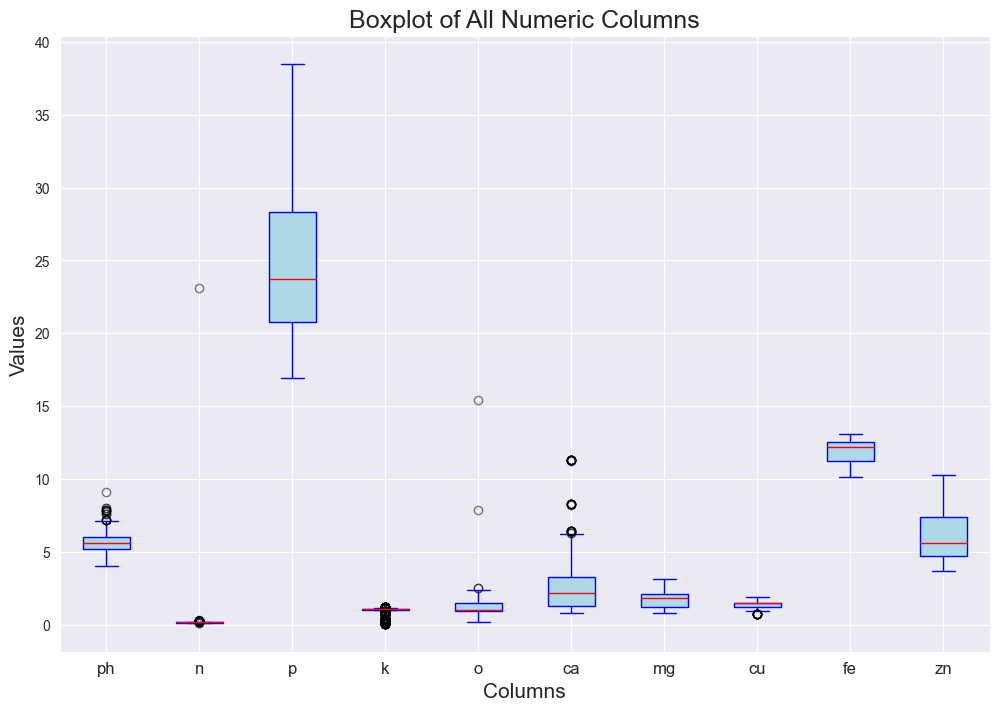

In [24]:
# Create a figure with a specified size
plt.figure(figsize=(12, 8))

# Create a boxplot for all numeric columns in the dataset
df_clean.boxplot(patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
             medianprops=dict(color='red'), whiskerprops=dict(color='blue'),
             capprops=dict(color='blue'), flierprops=dict(marker='o', color='blue', alpha=0.5))

# Add a title and labels for the axes
plt.title("Boxplot of All Numeric Columns", fontsize=18)
plt.xlabel("Columns", fontsize=15)
plt.ylabel("Values", fontsize=15)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=0, fontsize=12)

# Add grid lines for better readability
plt.grid(True)

# Display the plot
plt.show()

In [25]:
def check_outliers(df):
    # List to store outlier details for each column
    outlier_data = []

    # Loop through numeric columns
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        # Compute Q1, Q3, and IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Compute outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = outliers.shape[0]
        outlier_percentage = (outlier_count / df.shape[0]) * 100

        # Append details to the list
        outlier_data.append({
            'column': col,
            'outlier_count': outlier_count,
            'outlier_percentage': outlier_percentage,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        })

    # Convert list to DataFrame
    outlier_df = pd.DataFrame(outlier_data)
    return outlier_df

In [26]:
check_outliers(df_clean)

,column,outlier_count,outlier_percentage,lower_bound,upper_bound
0,ph,16,1.6,4.000000e+00,7.200
1,n,62,6.2,9.500000e-02,0.215
2,p,0,0.0,9.550000e+00,39.550
3,k,301,30.1,9.700000e-01,1.130
4,o,4,0.4,1.110223e-16,2.400
5,ca,28,2.8,-1.700000e+00,6.300
6,mg,0,0.0,-1.500000e-01,3.450
7,cu,10,1.0,7.500000e-01,1.950
8,fe,0,0.0,9.250000e+00,14.450
9,zn,0,0.0,6.500000e-01,11.450


The analysis show presence of outliers in the dataset more so on the Potassium column(K) with 30.1 % outlier values

### Explanatory Data Analysis

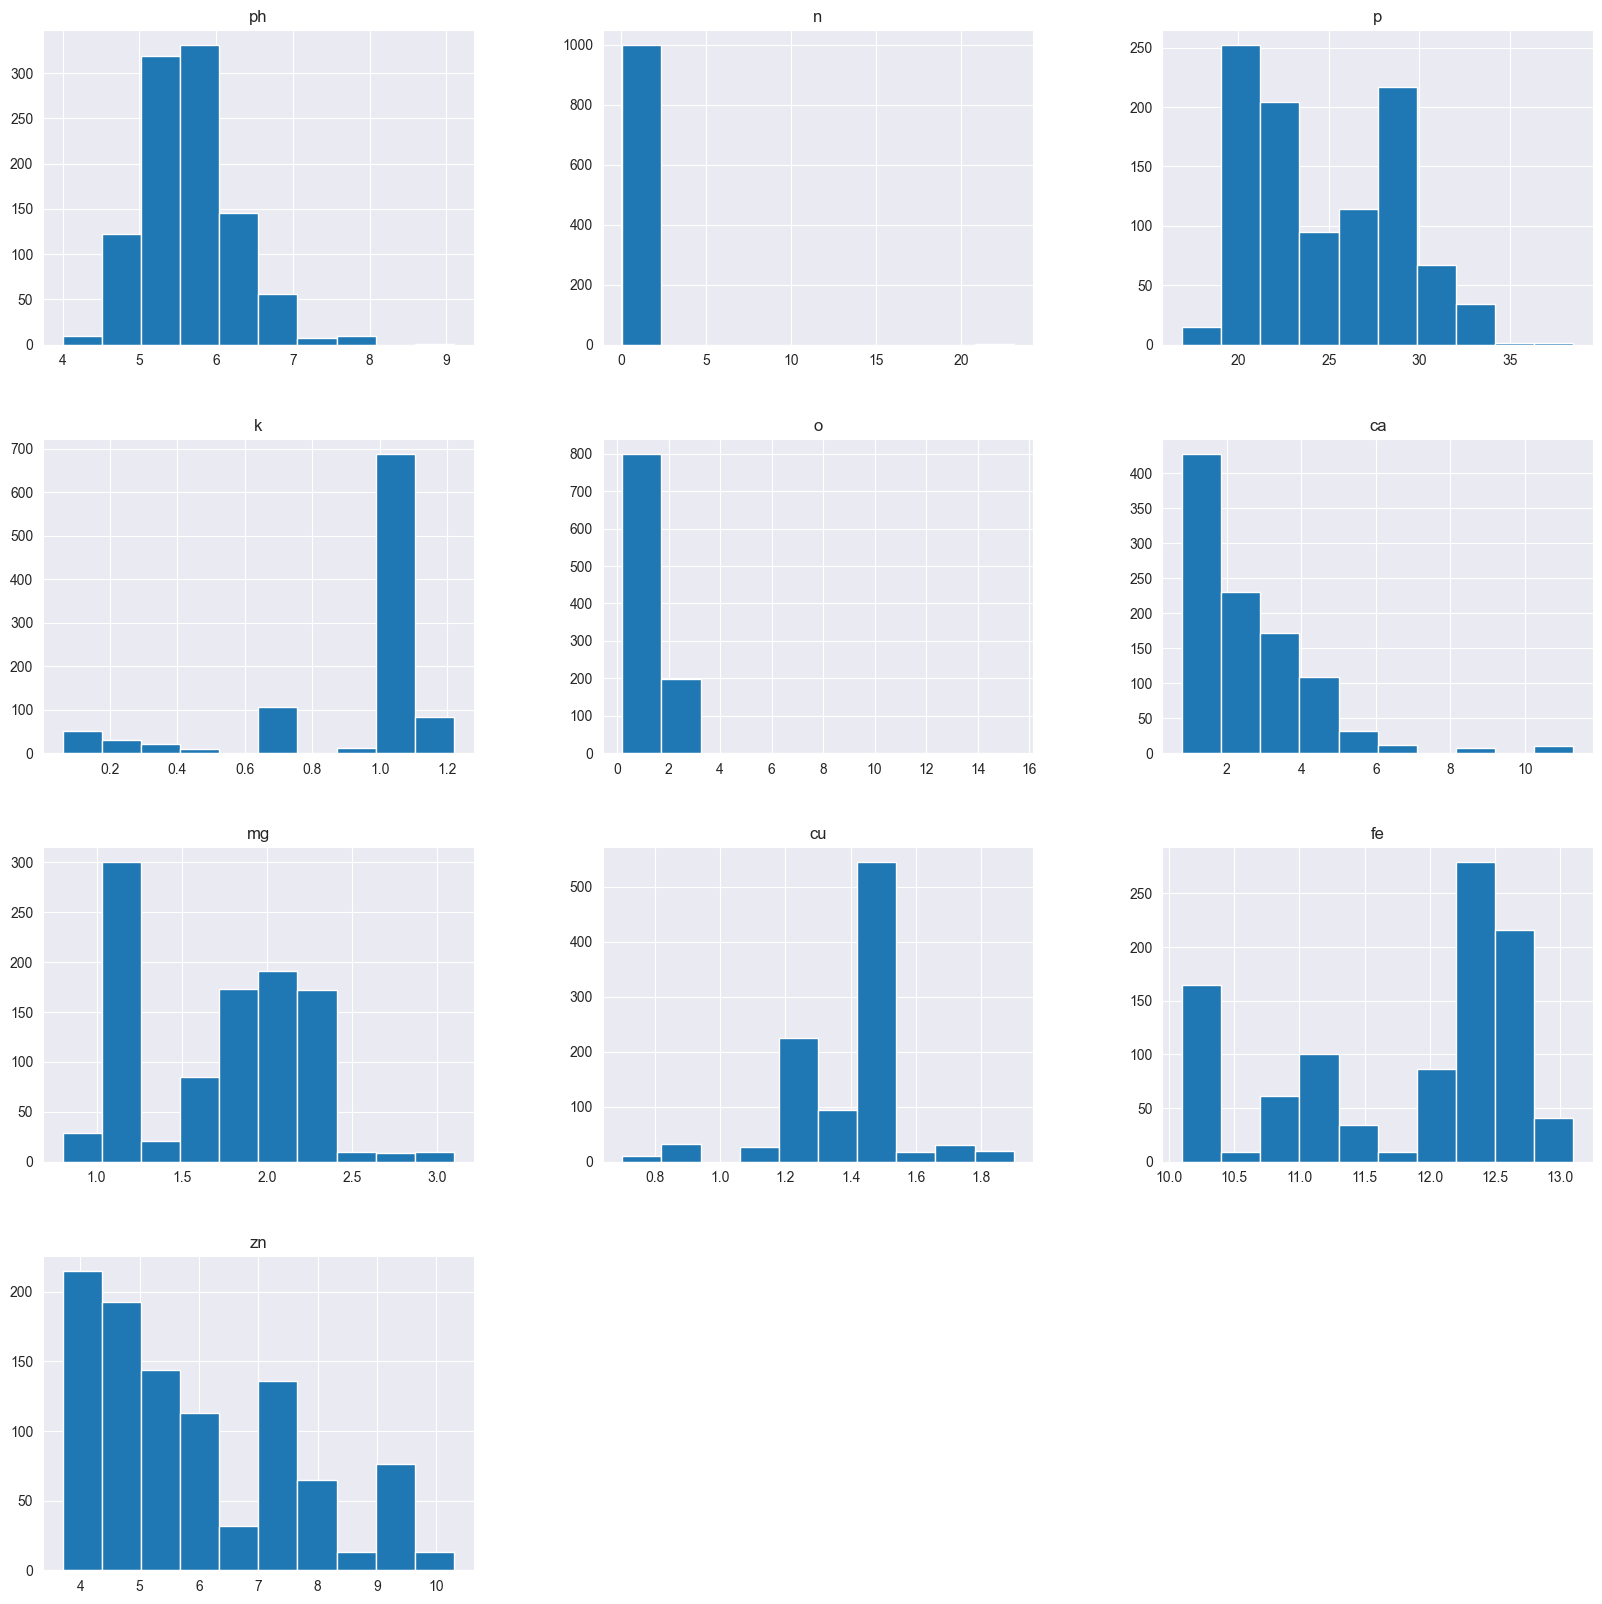

In [27]:
# histogram of the dataset
df_clean.hist(figsize=(20, 20))

plt.show()

#### 1. Univariate Analyis

/var/folders/k3/6rk4z8696pz8g275b3dtg8kh0000gn/T/ipykernel_9463/3742994308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['soilfertilitystatus'], ax=ax, palette='Set2')


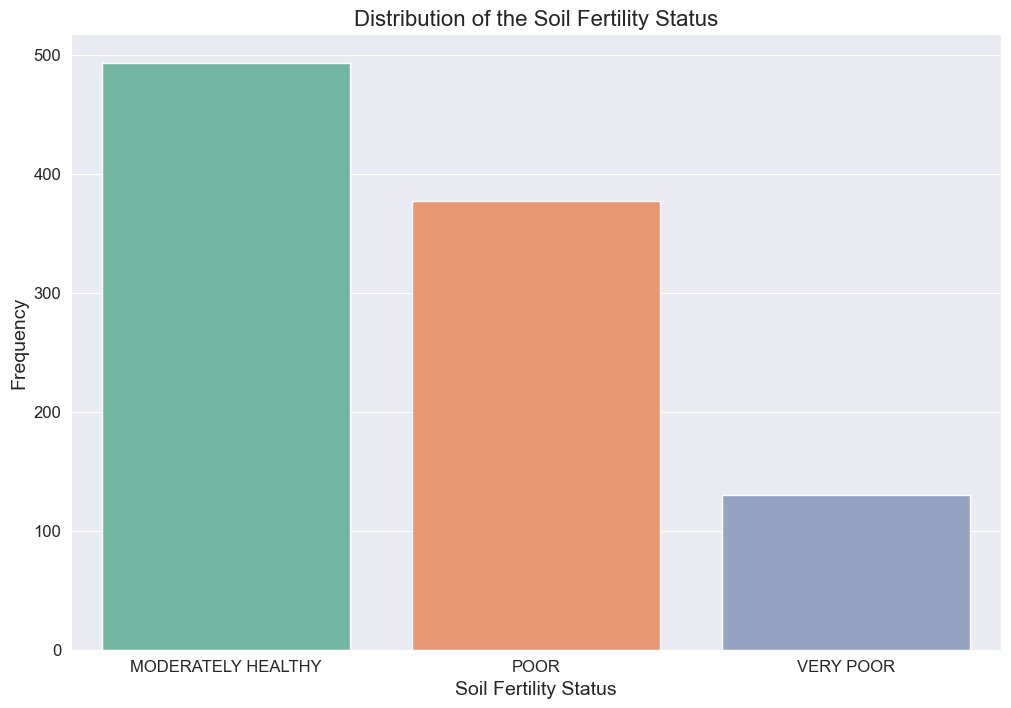

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x=df_clean['soilfertilitystatus'], ax=ax, palette='Set2')

plt.title("Distribution of the Soil Fertility Status", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Soil Fertility Status", fontsize=14)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/soil_fertility_status_plot.png'
plt.savefig(plot_path, dpi=300)

plt.show()

/var/folders/k3/6rk4z8696pz8g275b3dtg8kh0000gn/T/ipykernel_9463/1338068663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['simpliedtexture(1)'], ax=ax, palette='Set2')


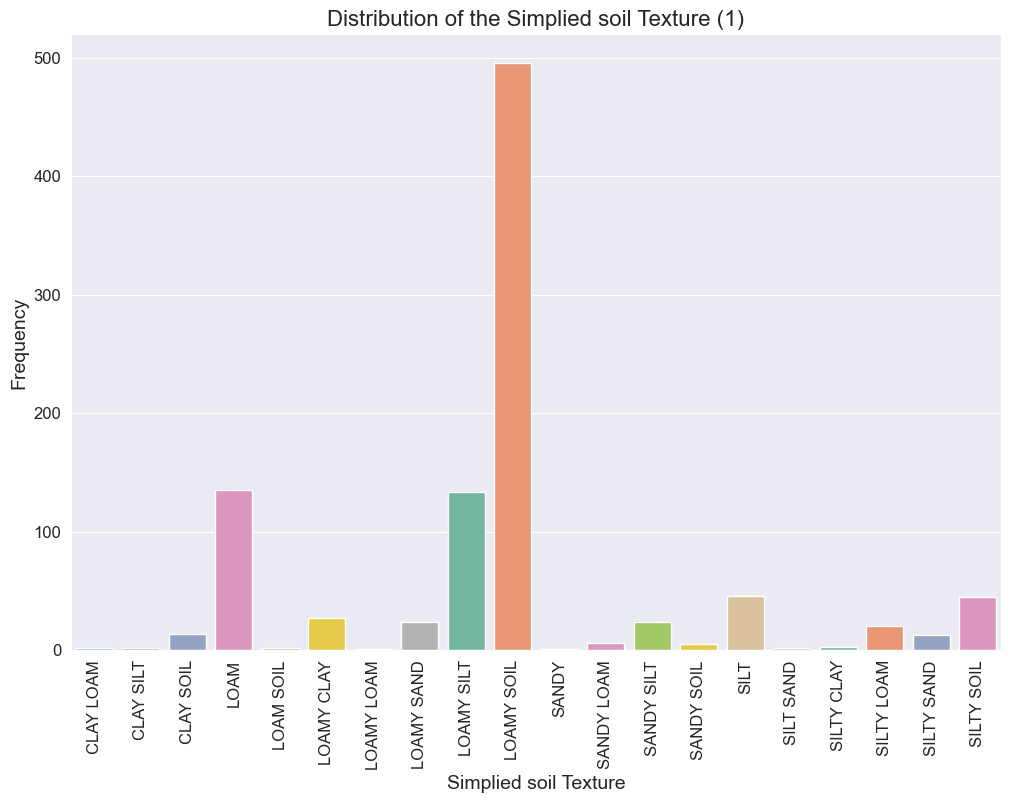

In [29]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x=df_clean['simpliedtexture(1)'], ax=ax, palette='Set2')

plt.title("Distribution of the Simplied soil Texture (1)", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Simplied soil Texture", fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/soil_texture_plot.png'
plt.savefig(plot_path, dpi=300)

plt.show()

/var/folders/k3/6rk4z8696pz8g275b3dtg8kh0000gn/T/ipykernel_9463/824741115.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['croprecommendation1'], ax=ax, palette='viridis')


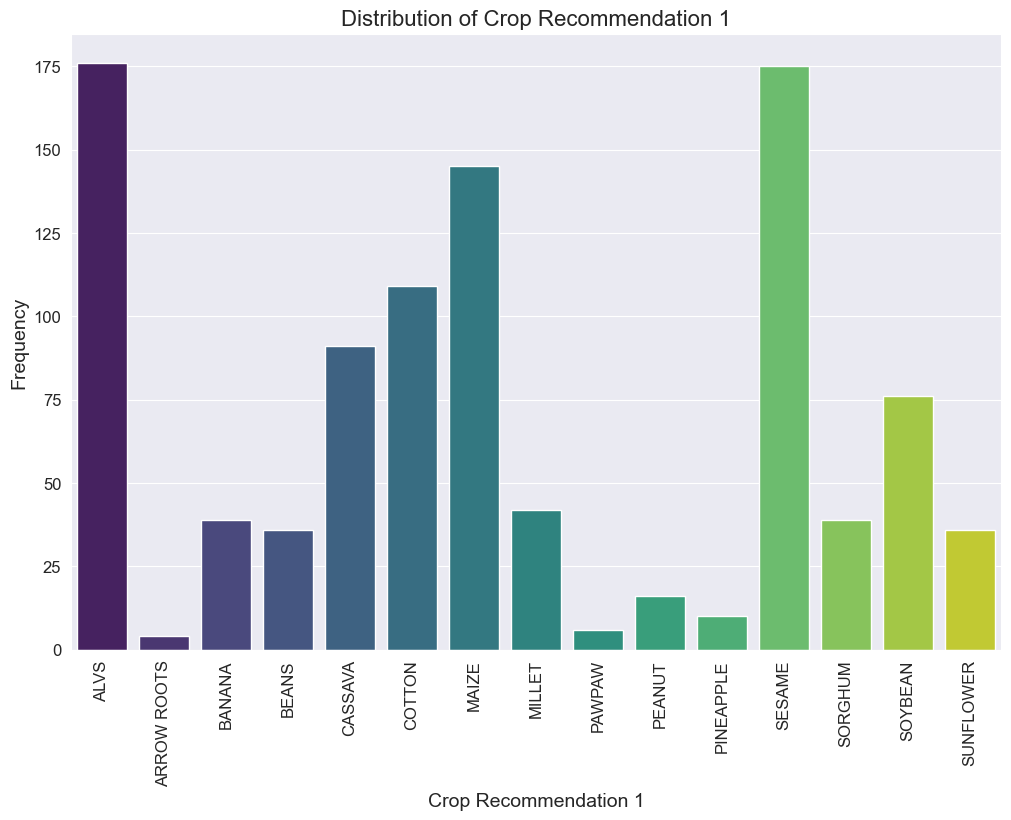

In [30]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x=df_clean['croprecommendation1'], ax=ax, palette='viridis')

plt.title("Distribution of Crop Recommendation 1", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Crop Recommendation 1", fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/crop_recommendation_1_plot.png'
plt.savefig(plot_path, dpi=300)

plt.show()

/var/folders/k3/6rk4z8696pz8g275b3dtg8kh0000gn/T/ipykernel_9463/4205834284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['croprecommendation2'], ax=ax, palette='viridis')


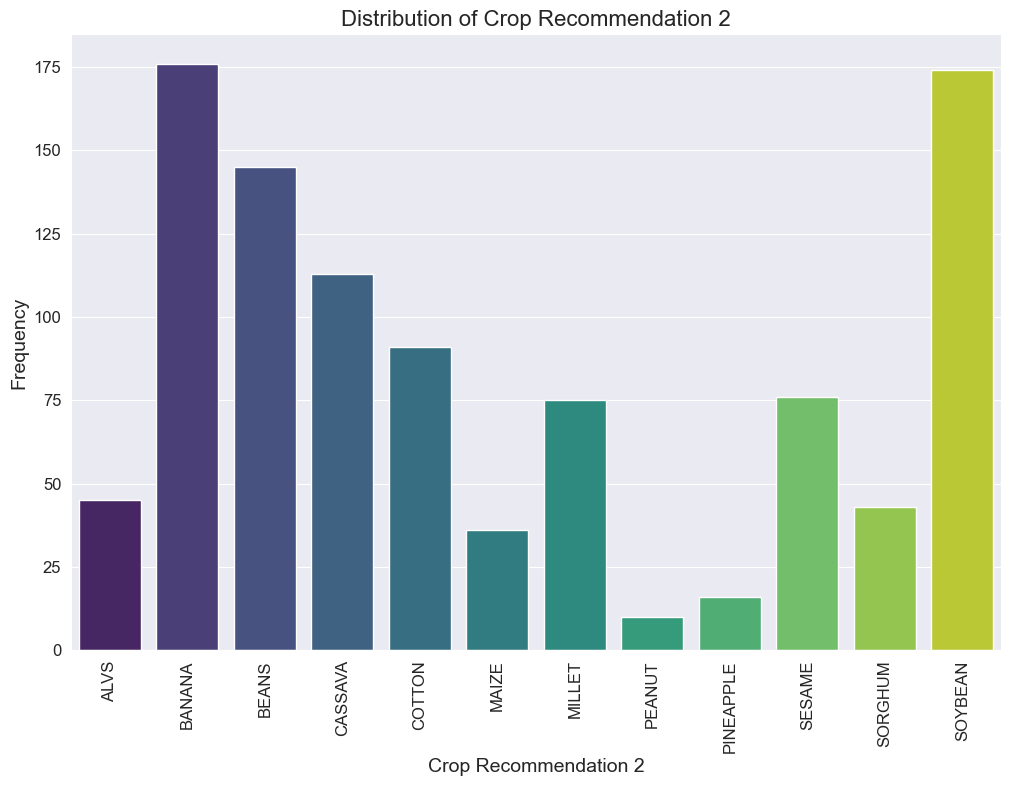

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x=df_clean['croprecommendation2'], ax=ax, palette='viridis')

plt.title("Distribution of Crop Recommendation 2", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Crop Recommendation 2", fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/Crop Recommendation 2_plot.png'
plt.savefig(plot_path, dpi=300)

plt.show()

/var/folders/k3/6rk4z8696pz8g275b3dtg8kh0000gn/T/ipykernel_9463/3245676672.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['fertilizerrecommendation1'], ax=ax, palette='magma')


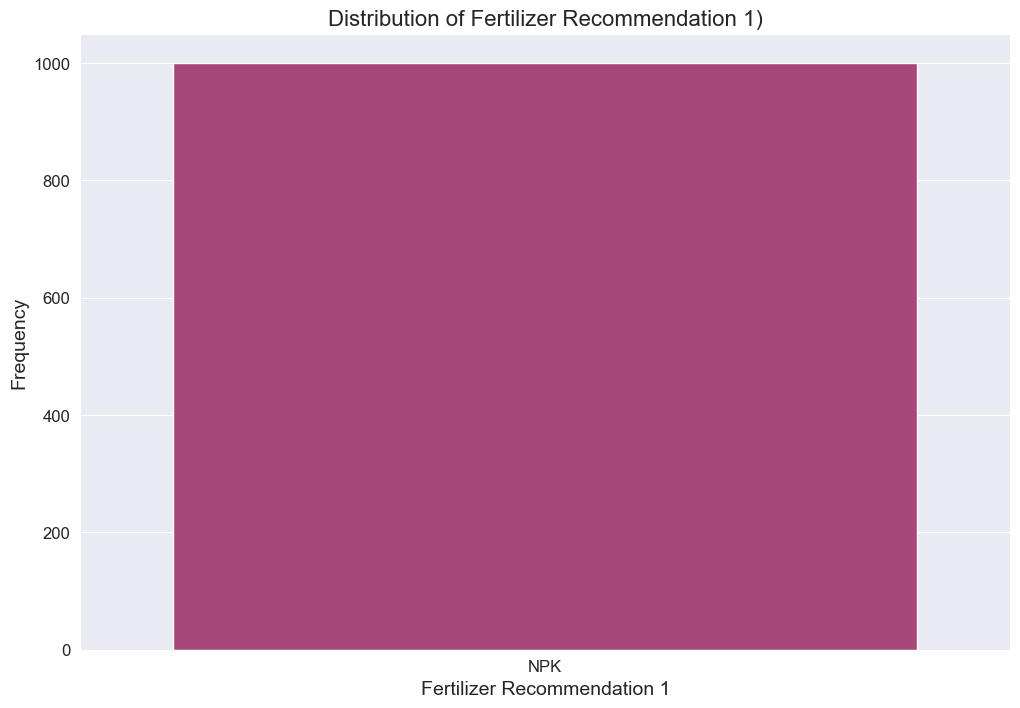

In [32]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x=df_clean['fertilizerrecommendation1'], ax=ax, palette='magma')

plt.title("Distribution of Fertilizer Recommendation 1)", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Fertilizer Recommendation 1", fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/fertilizer_recommendation_1_plot.png'
plt.savefig(plot_path, dpi=300)

plt.show()

/var/folders/k3/6rk4z8696pz8g275b3dtg8kh0000gn/T/ipykernel_9463/3230084628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['fertilizerrecommendation2'], ax=ax, palette='viridis')


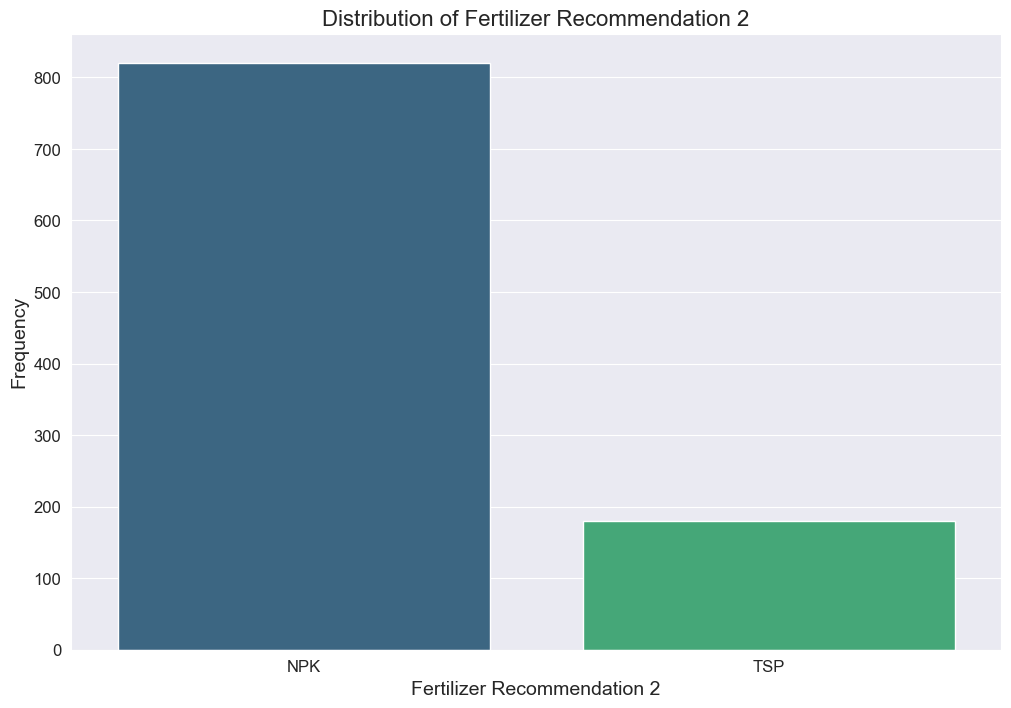

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x=df_clean['fertilizerrecommendation2'], ax=ax, palette='viridis')

plt.title("Distribution of Fertilizer Recommendation 2", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Fertilizer Recommendation 2", fontsize=14)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/fertilizer_recommendation_2_plot.png'
plt.savefig(plot_path, dpi=300)

plt.show()

#### 2. Bivariate Analysis

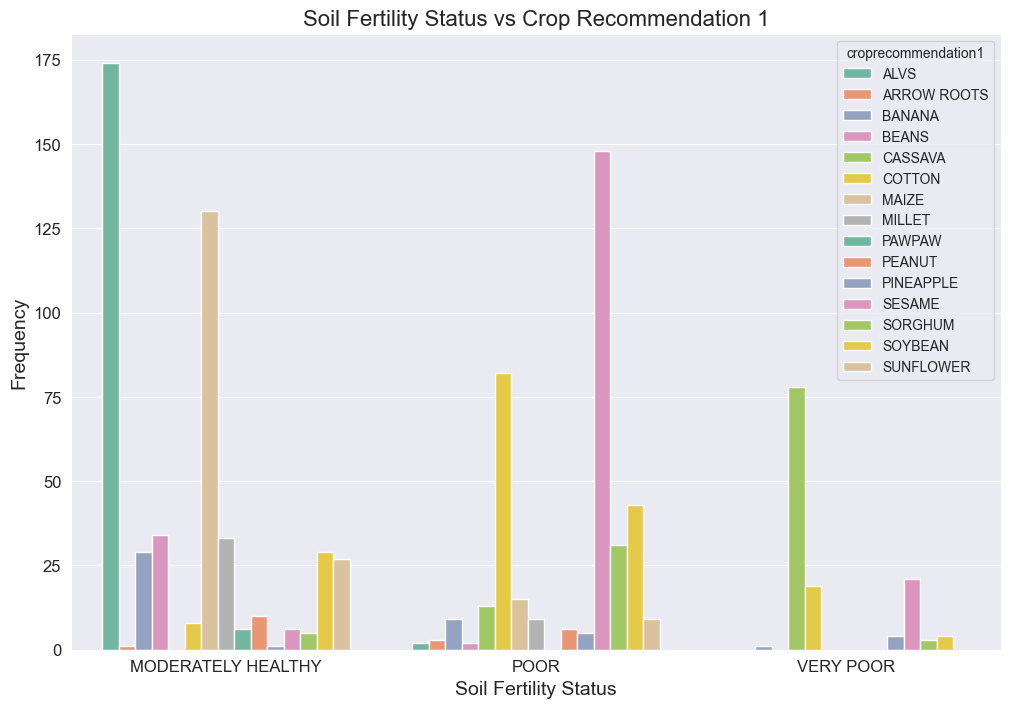

In [34]:
# The relationship between Soil Fertility Status and Crop Recommendation 1

fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x='soilfertilitystatus', hue='croprecommendation1', data=df_clean, palette='Set2', ax=ax)

plt.title("Soil Fertility Status vs Crop Recommendation 1", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Soil Fertility Status", fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/soil_fertility_vs_crop_recommendation_1.png'
plt.savefig(plot_path, dpi=300) 

plt.show()

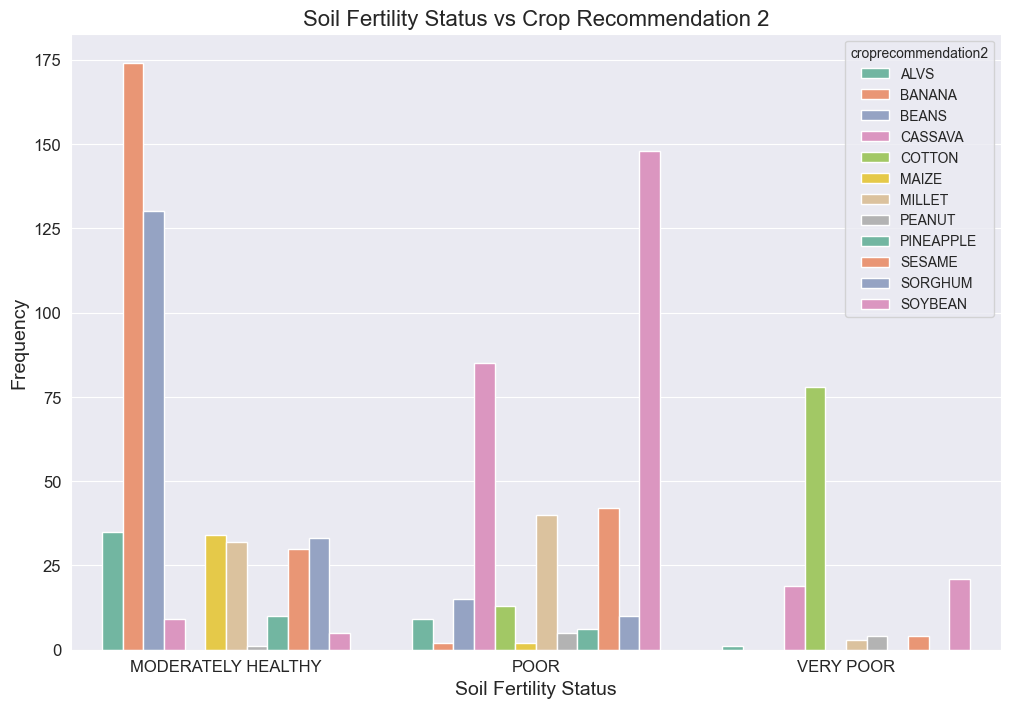

In [35]:
# The relationship between Soil Fertility Status and Crop Recommendation 2

fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x='soilfertilitystatus', hue='croprecommendation2', data=df_clean, palette='Set2', ax=ax)

plt.title("Soil Fertility Status vs Crop Recommendation 2", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Soil Fertility Status", fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/soil_fertility_vs_crop_recommendation_2.png'
plt.savefig(plot_path, dpi=300) 

plt.show()

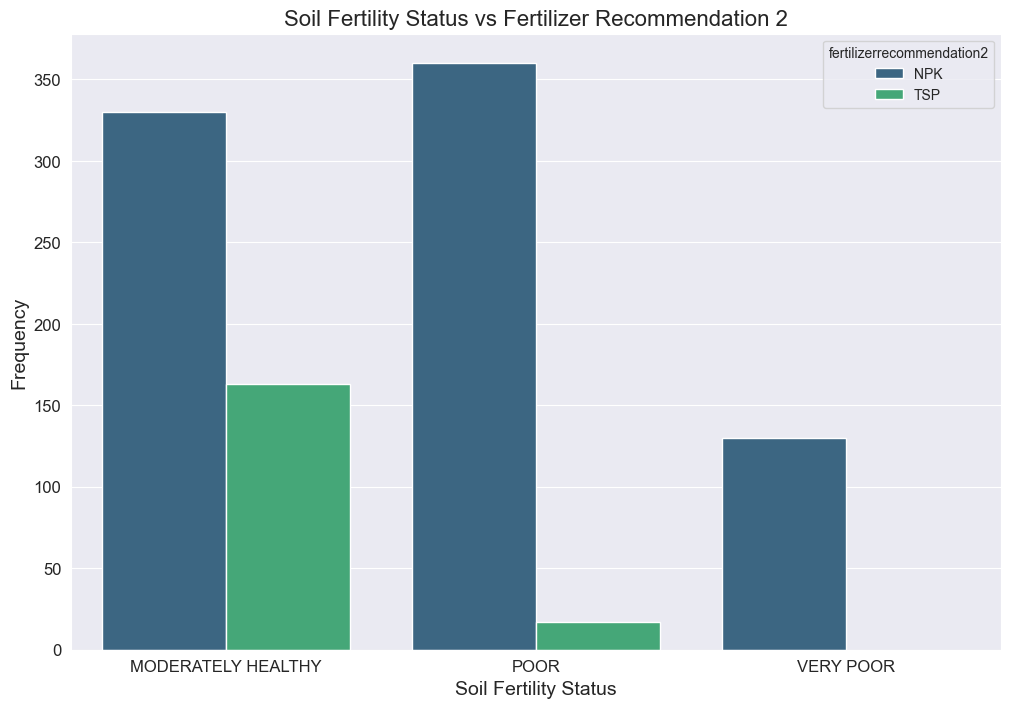

In [36]:
# The relationship between Soil Fertility Status and Crop Recommendation 1

fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x='soilfertilitystatus', hue='fertilizerrecommendation2', data=df_clean, palette='viridis', ax=ax)

plt.title("Soil Fertility Status vs Fertilizer Recommendation 2", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Soil Fertility Status", fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/soil_fertility_vs_crop_recommendation_1.png'
plt.savefig(plot_path, dpi=300) 

plt.show()

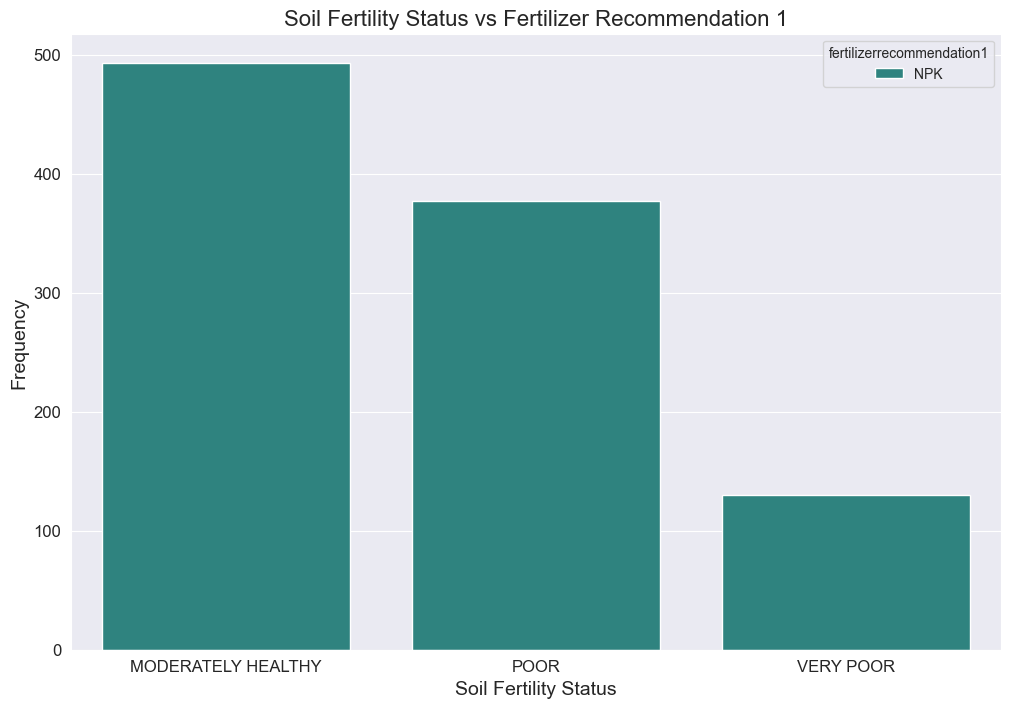

In [37]:
# The relationship between Soil Fertility Status and Crop Recommendation 1

fig, ax = plt.subplots(figsize=(12, 8))
sns.countplot(x='soilfertilitystatus', hue='fertilizerrecommendation1', data=df_clean, palette='viridis', ax=ax)

plt.title("Soil Fertility Status vs Fertilizer Recommendation 1", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Soil Fertility Status", fontsize=14)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Saving the plot with higher resolution
plot_path = '../eda_charts/soil_fertility_vs_crop_recommendation_1.png'
plt.savefig(plot_path, dpi=300) 

plt.show()

#### 3. Multivariate Analysis

In [38]:
# Ensure df_clean contains only numerical data
df_clean_numeric = df_clean.select_dtypes(include=['number'])

# Compute the correlation matrix if needed
correlation_matrix = df_clean_numeric.corr()

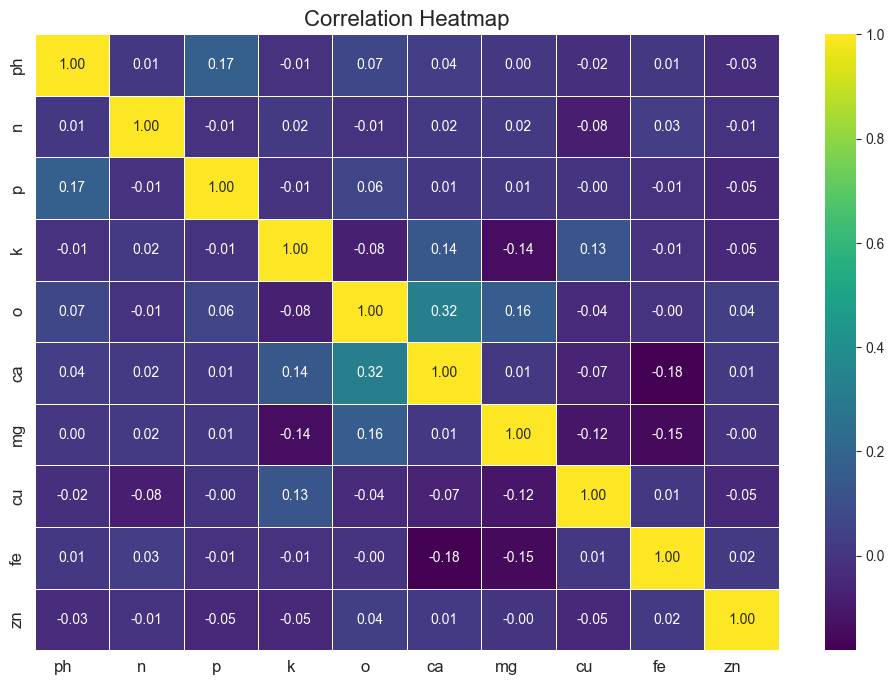

In [39]:
# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='viridis', ax=ax, linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=0, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Saving the heatmap with higher resolution
heatmap_path = '../eda_charts/soil_correlation_heatmap.png'
plt.savefig(heatmap_path, dpi=300)

plt.show()

### Data Preparation

In [31]:
# %pip install imblearn

In [32]:
# Importing necessary libraries for preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

#### 1. Encoding Categorical Columns

In [33]:
# Encoding categorical values
def encode_categorical_columns(df: pd.DataFrame, encoding_type: str = 'label') -> pd.DataFrame:
    """
    Encodes categorical columns in a DataFrame.

    Parameters:
        df (pd.DataFrame): The input DataFrame with categorical columns.
        encoding_type (str): The encoding type, either 'label' or 'onehot'.

    Returns:
        pd.DataFrame: A DataFrame with encoded categorical columns.
    """

    df_encoded = df.copy()

    categorical_columns = df_encoded.select_dtypes(include=['category']).columns

    if encoding_type == 'label':
        for col in categorical_columns:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col])

    elif encoding_type == 'onehot':
        df_encoded = pd.get_dummies(df_encoded, columns=categorical_columns, drop_first=True)
    else:
        raise ValueError("Unsupported encoding_type. Use 'label' or 'onehot' .")


    return df_encoded

In [34]:
# Preview of data before encoding
df_clean.sample(5)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,croprecommendation1,croprecommendation2,fertilizerrecommendation1,fertilizerrecommendation2
138,SILT,5.9,0.20,21.2,1.10,1.8,1.7,2.2,1.5,12.5,3.9,MODERATELY HEALTHY,MILLET,SORGHUM,NPK,NPK
702,LOAMY SOIL,5.6,0.18,19.7,1.07,0.5,0.8,2.1,1.5,11.9,3.9,POOR,COTTON,CASSAVA,NPK,NPK
597,LOAMY SOIL,5.7,0.14,20.8,1.08,1.8,3.3,1.6,1.5,10.3,3.9,MODERATELY HEALTHY,MAIZE,BEANS,NPK,TSP
380,LOAMY SOIL,6.1,0.17,23.7,1.07,1.0,1.2,1.9,1.5,12.7,5.7,MODERATELY HEALTHY,ALVS,BANANA,NPK,NPK
607,LOAMY SOIL,5.9,0.18,23.7,1.07,0.7,3.3,2.0,1.3,11.8,5.3,MODERATELY HEALTHY,SUNFLOWER,MILLET,NPK,NPK


In [35]:
# encoding the categorical columns

df_encoded = encode_categorical_columns(df_clean, encoding_type='label')
df_encoded.sample(5)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,croprecommendation1,croprecommendation2,fertilizerrecommendation1,fertilizerrecommendation2
290,9,5.0,0.15,22.2,1.07,1.2,3.4,1.0,1.5,12.0,4.9,2,4,4,0,0
304,9,5.8,0.16,21.4,1.07,0.5,1.7,1.0,1.5,11.2,4.9,0,5,3,0,0
882,19,5.4,0.17,19.7,1.02,1.0,4.0,1.5,1.2,10.8,5.6,1,5,3,0,0
901,9,5.4,0.14,29.2,1.07,0.8,3.3,2.0,1.3,11.8,7.4,1,11,11,0,0
696,9,5.1,0.17,27.2,1.07,0.8,1.7,1.0,1.5,11.2,4.9,1,4,4,0,0


In [36]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   simpliedtexture(1)         1000 non-null   int64  
 1   ph                         1000 non-null   float64
 2   n                          1000 non-null   float64
 3   p                          1000 non-null   float64
 4   k                          1000 non-null   float64
 5   o                          1000 non-null   float64
 6   ca                         1000 non-null   float64
 7   mg                         1000 non-null   float64
 8   cu                         1000 non-null   float64
 9   fe                         1000 non-null   float64
 10  zn                         1000 non-null   float64
 11  soilfertilitystatus        1000 non-null   int64  
 12  croprecommendation1        1000 non-null   int64  
 13  croprecommendation2        1000 non-null   int64 

In [37]:
df_encoded['soilfertilitystatus'].value_counts()

soilfertilitystatus
0    493
1    377
2    130
Name: count, dtype: int64

In [38]:
df_clean["soilfertilitystatus"].value_counts()

soilfertilitystatus
MODERATELY HEALTHY    493
POOR                  377
VERY POOR             130
Name: count, dtype: int64

In [39]:
#df_encoded['soilfertilitystatus'].value_counts()

#### 2. Scaling the values

In [40]:
# scaling the values

def scale_dataset(df: pd.DataFrame,target_column : str , scaling_type: str = 'standard') -> pd.DataFrame:
    """
    Scales numerical columns in the DataFrame.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        scaling_type (str): The type of scaling to apply, either 'standard' or 'minmax'.

    Returns:
        pd.DataFrame: A DataFrame with scaled numerical columns.
    """
    df_scaled = df.copy()

    # select numeric columns
    numerical_columns = df_scaled.select_dtypes(include=['float64']).columns
    columns_to_scale = numerical_columns.difference([target_column])

    if scaling_type == 'standard':
        scaler = StandardScaler()
    elif scaling_type == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("Unsupported scaling_type. Use 'standard' or 'minmax'. ")

    df_scaled[columns_to_scale] = scaler.fit_transform(df_scaled[columns_to_scale])

    return df_scaled

In [41]:
# Preview of data before scaling
df_encoded.sample(5)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,croprecommendation1,croprecommendation2,fertilizerrecommendation1,fertilizerrecommendation2
27,18,6.4,0.23,22.9,1.07,1.8,5.2,1.1,1.5,12.2,5.6,0,7,10,0,0
428,9,6.1,0.24,19.4,1.21,1.5,1.1,2.1,1.1,12.9,7.4,0,0,1,0,0
949,9,5.6,0.14,19.8,1.10,1.8,1.7,2.2,1.5,12.5,5.2,1,13,9,0,0
437,8,5.9,0.18,19.4,1.10,1.0,3.3,2.0,0.9,12.7,7.4,0,6,2,0,1
203,18,5.0,0.14,19.4,1.07,1.2,3.3,1.1,1.5,10.9,4.3,2,11,11,0,0


In [42]:
# scaling the dataset
df_scaled = scale_dataset(df_encoded, scaling_type = 'standard', target_column = 'soilfertilitystatus')
df_scaled.sample(5)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,croprecommendation1,croprecommendation2,fertilizerrecommendation1,fertilizerrecommendation2
857,9,0.234927,-0.021295,-1.168234,0.443141,-0.466338,-0.533842,0.383356,0.543536,-1.668401,1.333523,0,13,9,0,0
276,7,-0.625611,-0.048862,2.185387,0.795288,-0.466338,-0.779966,-1.131029,-0.999140,1.056446,-1.063217,1,13,9,0,0
257,3,-0.969827,-0.048862,-0.593327,0.443141,1.503115,0.266060,1.032378,0.543536,0.488769,1.333523,1,11,11,0,0
131,3,0.062819,-0.021295,-0.569373,-0.789372,1.362440,1.065962,-1.131029,0.543536,1.056446,1.976551,0,0,1,0,0
379,9,0.234927,-0.021295,0.292987,0.443141,-0.466338,0.019936,0.167015,0.543536,0.488769,-0.361732,0,14,6,0,0


#### 3. Class balancing of the target column

In [43]:
df_clean['soilfertilitystatus'].value_counts()

soilfertilitystatus
MODERATELY HEALTHY    493
POOR                  377
VERY POOR             130
Name: count, dtype: int64

In [44]:
df_scaled['soilfertilitystatus'].value_counts()

soilfertilitystatus
0    493
1    377
2    130
Name: count, dtype: int64

In [45]:
# checking for class imbalance

def balance_with_smote(df: pd.DataFrame, target_column: str):
    """
    Apply SMOTE to balance the dataset.

    Parameters:
        df (pd.DataFrame): Input DataFrame (encoded and scaled).
        target_column (str): Name of the target column.

    Returns:
        X_resampled (pd.DataFrame): Resampled feature set.
        y_resampled (pd.Series): Resampled target column.
    """
    X = df.drop(columns=[target_column])
    y = df[target_column]

    smote = SMOTE(random_state=142)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # Convert back to DataFrame
    X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
    y_resampled = pd.Series(y_resampled, name=target_column)

    return X_resampled, y_resampled

In [46]:
df_clean.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation1',
       'croprecommendation2', 'fertilizerrecommendation1',
       'fertilizerrecommendation2'],
      dtype='object')

In [47]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   simpliedtexture(1)         1000 non-null   int64  
 1   ph                         1000 non-null   float64
 2   n                          1000 non-null   float64
 3   p                          1000 non-null   float64
 4   k                          1000 non-null   float64
 5   o                          1000 non-null   float64
 6   ca                         1000 non-null   float64
 7   mg                         1000 non-null   float64
 8   cu                         1000 non-null   float64
 9   fe                         1000 non-null   float64
 10  zn                         1000 non-null   float64
 11  soilfertilitystatus        1000 non-null   int64  
 12  croprecommendation1        1000 non-null   int64  
 13  croprecommendation2        1000 non-null   int64 

In [48]:
df_scaled.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation1',
       'croprecommendation2', 'fertilizerrecommendation1',
       'fertilizerrecommendation2'],
      dtype='object')

In [49]:
# Saving the dataset after the preprocessing step to use it to model the fertilizer classifier
df_clean.to_csv("../data/data_for_fertilizer_classification.csv", index=False)

### Preprocessing and saving the preprocessed file 

In [50]:
# DROP unecessary columns first

df_clean = df_clean.drop(columns=['croprecommendation1', 'croprecommendation2', 'fertilizerrecommendation1', 'fertilizerrecommendation2' ])
df_clean.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus'],
      dtype='object')

In [51]:
df_clean.head()

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus
0,SILTY SOIL,4.9,0.14,22.9,0.14,1.1,1.3,2.2,1.2,10.1,5.6,VERY POOR
1,LOAMY SOIL,5.7,0.14,28.3,0.27,1.3,1.8,2.1,1.2,12.9,5.2,MODERATELY HEALTHY
2,SILTY LOAM,5.9,0.16,23.1,0.39,2.1,1.6,2.5,1.2,10.1,6.4,MODERATELY HEALTHY
3,LOAMY SOIL,5.7,0.20,29.2,0.47,2.1,2.8,2.2,1.2,12.0,7.4,MODERATELY HEALTHY
4,LOAM,5.7,0.14,28.3,0.28,2.2,3.2,1.4,1.2,12.3,7.0,MODERATELY HEALTHY


In [52]:
df_clean.head()

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus
0,SILTY SOIL,4.9,0.14,22.9,0.14,1.1,1.3,2.2,1.2,10.1,5.6,VERY POOR
1,LOAMY SOIL,5.7,0.14,28.3,0.27,1.3,1.8,2.1,1.2,12.9,5.2,MODERATELY HEALTHY
2,SILTY LOAM,5.9,0.16,23.1,0.39,2.1,1.6,2.5,1.2,10.1,6.4,MODERATELY HEALTHY
3,LOAMY SOIL,5.7,0.20,29.2,0.47,2.1,2.8,2.2,1.2,12.0,7.4,MODERATELY HEALTHY
4,LOAM,5.7,0.14,28.3,0.28,2.2,3.2,1.4,1.2,12.3,7.0,MODERATELY HEALTHY


In [53]:
# from api.preprocessing import SoilDataPreprocessor

In [54]:
# During training phase
preprocessor = SoilDataPreprocessor()

# Fit and transform training data
train_data_processed = preprocessor.fit_transform(
    df_clean, 
    target_column='soilfertilitystatus',
    encoding_type='label',
    scaling_type='standard',
    apply_smote=False   # this is set to False to avoid oversampling using SMOTE
)

2026-02-03 15:47:30,946 - SoilDataPreprocessor - INFO - SoilDataPreprocessor initialized
2026-02-03 15:47:30,949 - SoilDataPreprocessor - INFO - ============================================================
2026-02-03 15:47:30,952 - SoilDataPreprocessor - INFO - Starting fit_transform process
2026-02-03 15:47:30,954 - SoilDataPreprocessor - INFO - Parameters - encoding: label, scaling: standard, SMOTE: False
2026-02-03 15:47:30,955 - SoilDataPreprocessor - INFO - Input DataFrame shape: (1000, 12)
2026-02-03 15:47:30,957 - SoilDataPreprocessor - INFO - Target column: soilfertilitystatus
2026-02-03 15:47:30,959 - SoilDataPreprocessor - INFO - Target column data type: category
2026-02-03 15:47:30,965 - SoilDataPreprocessor - INFO - Target classes: ['VERY POOR', 'MODERATELY HEALTHY', 'POOR']
Categories (3, object): ['MODERATELY HEALTHY', 'POOR', 'VERY POOR']
Overall Progress:   0%|          | 0/2 [00:00<?, ?step/s]2026-02-03 15:47:30,994 - SoilDataPreprocessor - INFO - ---------------------

In [55]:
# lets create csv of the preprocessed soil fertility status dataset to only focus on major nutrients in a separate notebook
train_data_processed.to_csv("../data/data_for_macro_nutrients_ph_org_classification.csv", index=False)

In [64]:
# saving the preprocessor
preprocessor.save('models/soil_fertility_status_preprocessor.joblib')

2026-01-27 16:46:42,890 - SoilDataPreprocessor - INFO - Saving preprocessor to: models/soil_fertility_status_preprocessor.joblib
Saving preprocessor: 100%|██████████| 1/1 [00:00<00:00, 268.81file/s]
2026-01-27 16:46:42,901 - SoilDataPreprocessor - INFO - Preprocessor saved successfully


In [63]:
train_data_processed.sample(10)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus
50,14,-0.453504,-0.076428,0.580440,0.443141,-0.184988,-0.533842,-1.131029,0.543536,0.488769,1.976551,1
597,9,0.062819,-0.062645,-0.928690,0.478356,0.799739,0.450653,-0.265666,0.543536,-1.668401,-1.238589,0
958,8,-0.969827,-0.062645,-1.168234,0.443141,-0.466338,-0.903028,-1.131029,0.543536,-1.668401,-0.303275,1
910,9,-0.625611,-0.062645,-1.168234,-2.374031,-0.044313,-0.472312,0.816037,-0.999140,1.283516,-0.654018,1
676,9,-1.141934,-0.021295,-1.168234,-0.789372,-0.466338,-0.533842,-0.482007,-0.999140,1.056446,-1.004760,2
481,9,1.783896,-0.021295,2.185387,0.443141,-0.325663,-0.226188,1.032378,0.543536,0.488769,-0.712475,0
191,3,-1.314042,-0.048862,-1.407778,0.443141,-0.184988,0.204529,0.167015,0.029311,-0.646583,1.333523,2
166,3,0.579142,0.020055,0.772075,0.443141,-0.325663,-0.533842,1.032378,-0.999140,0.488769,-1.004760,0
329,9,0.407035,-0.021295,0.867893,-0.789372,0.377713,-0.410781,1.032378,-0.999140,0.942910,-0.303275,0
325,9,-0.109288,-0.021295,-1.264052,-2.338816,1.081089,0.389122,-0.698348,-0.999140,0.602305,-0.069447,1


In [64]:
from sklearn.model_selection import train_test_split

X = train_data_processed.drop(columns=['soilfertilitystatus'])
y = train_data_processed['soilfertilitystatus']

print(f"X columns used: \n", X.columns)
print(f"\ny target columns:", y.name)

# splitting the dataset into train , test and validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=43)

X columns used: 
 Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn'],
      dtype='object')

y target columns: soilfertilitystatus


### Modelling

In [65]:
# %pip install xgboost

In [67]:
# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# model metrics libraries

from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report)

#### 1. Baseline Model

In [ ]:
# OneVsRestClassifier with LinearSVC 

# Initialize the OneVsRestClassifier with LinearSVC
OvR_clf = OneVsRestClassifier(
    LinearSVC(
        class_weight='balanced', # Introduces class imbalance handling
        random_state=42, 
        dual=False, 
        max_iter=5000
    )
)

# Fit the model on the training data
OvR_clf.fit(X_train, y_train)

# Predict on the test data
y_pred_ovr_clf = OvR_clf.predict(X_test)

In [69]:
# Model Evaluation for Logistic Regression
print("Multiclass with OneVsRest:")

# Accuracy is the ratio of correctly predicted observation to the total observations.
print(f"Accuracy: {accuracy_score(y_test, y_pred_ovr_clf):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_ovr_clf, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_ovr_clf, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. Therefore, this score takes both false positives and false negatives into account.
print(f"F1 Score: {f1_score(y_test, y_pred_ovr_clf, average='macro'):.4f}")

Multiclass with OneVsRest:
Accuracy: 0.9680
Precision: 0.9799
Recall: 0.9689
F1 Score: 0.9738


In [70]:
print("Classification report:\n", classification_report(y_test, y_pred_ovr_clf))

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       143
           1       0.99      0.91      0.95        81
           2       1.00      1.00      1.00        26

    accuracy                           0.97       250
   macro avg       0.98      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250



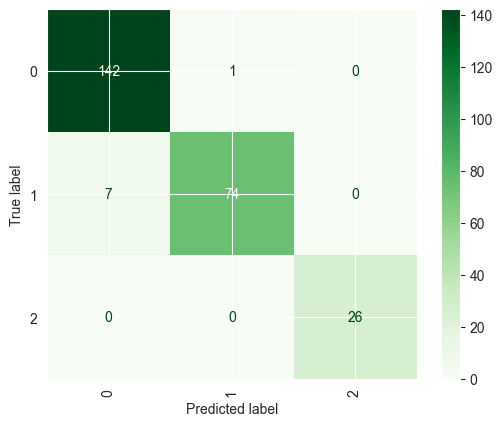

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_ovr_clf, labels=OvR_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=OvR_clf.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

# Saving the plot
plot_path = '../eda_charts/models_evals/one_versus_rest_confusion_matrix.png'
plt.savefig(plot_path)


Multiclass AUROC Score (Macro Average) for Soil Fertility Status One vs Rest Logistic Regression Classifier: 0.9913


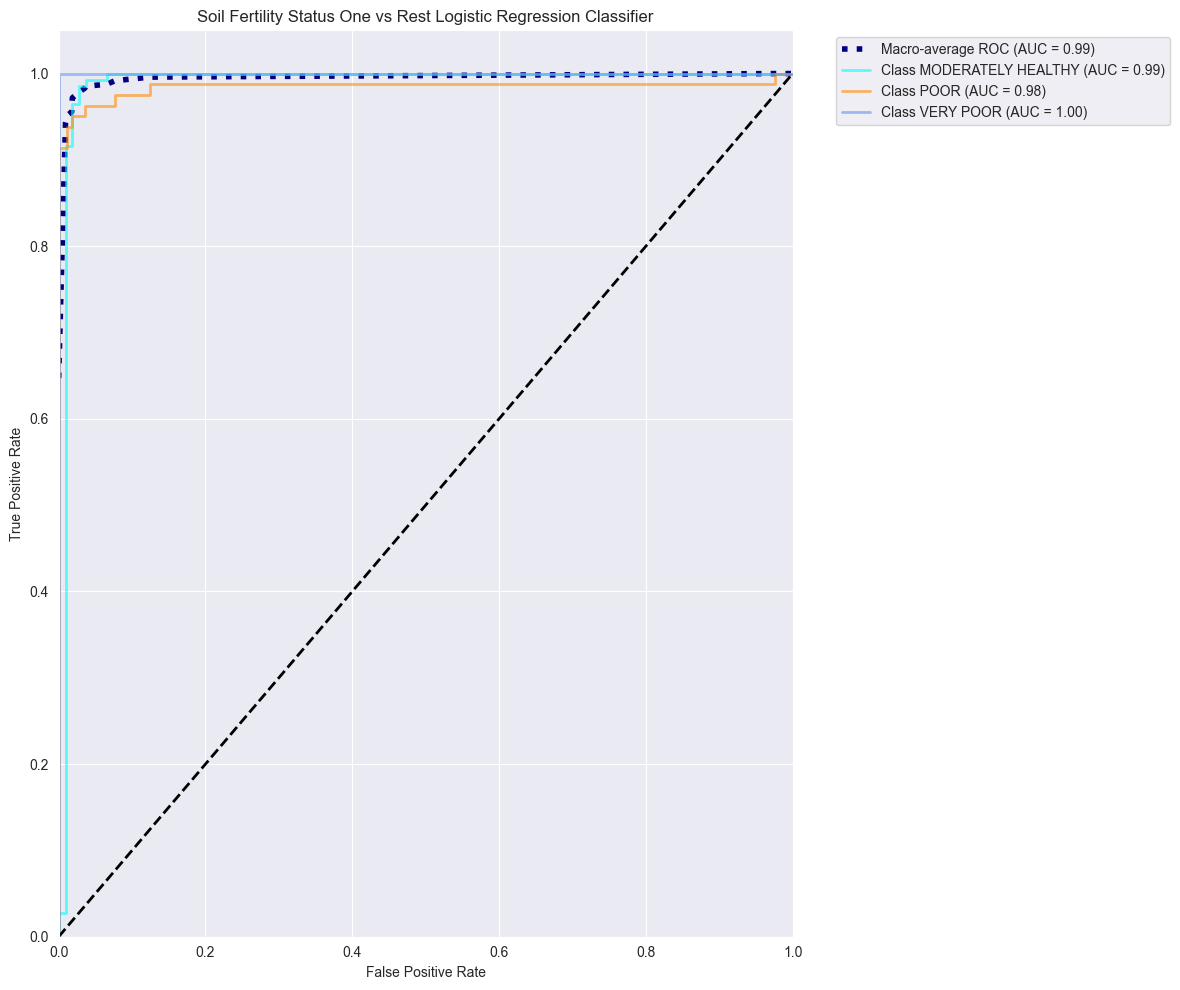

In [ ]:
from sklearn.preprocessing import LabelEncoder
from notebooks_utils.auroc_evaluate import evaluate_and_plot_multiclass_roc

# 1. Re-fit the encoder on your original target column to get the names back
le = LabelEncoder()
le.fit(df_clean['soilfertilitystatus'])

# 2. Get the class names
class_names = le.classes_ 

# Function to evaluate and plot the AUROC metrics
evaluate_and_plot_multiclass_roc(OvR_clf, X_test, y_test, class_names, title="Soil Fertility Status One vs Rest Logistic Regression Classifier")

In [73]:
# Save the model to a file
import joblib

joblib.dump(OvR_clf, '../models/Soil_Status_OneVsRest_Classifier_model.joblib')
print("OneVsRestClassifier models saved to: models/Soil_Status_OneVsRest_Classifier_model")

OneVsRestClassifier models saved to: models/Soil_Status_OneVsRest_Classifier_model


Observations:
- After Applying the class_weight = balanced on the model, the model performance improved 

#### 2. Decision Tree Models

In [74]:
# decision trees
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Fit the model on the training data
dtree.fit(X_train, y_train)

# Predict on the test data
y_pred_tree = dtree.predict(X_test)

In [75]:
print("Multiclass with Decision tree classifier:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_tree, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_tree, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall.
print(f"F1 Score: {f1_score(y_test, y_pred_tree, average='macro'):.4f}")

Multiclass with Decision tree classifier:
Accuracy: 0.9720
Precision: 0.9784
Recall: 0.9556
F1 Score: 0.9664


In [76]:
print("Classification report:\n", classification_report(y_test, y_pred_tree))

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       143
           1       0.96      0.95      0.96        81
           2       1.00      0.92      0.96        26

    accuracy                           0.97       250
   macro avg       0.98      0.96      0.97       250
weighted avg       0.97      0.97      0.97       250



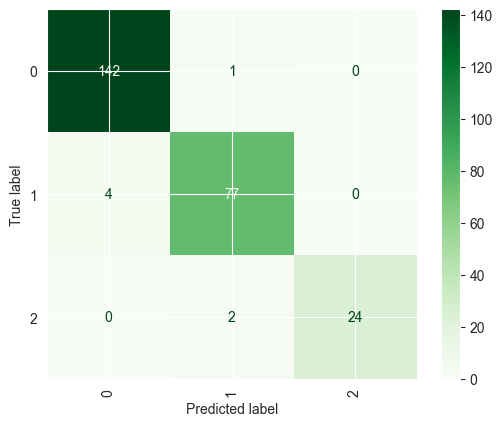

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tree, labels=dtree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

# Saving the plot
# plot_path = 'eda_charts/models_evals/decision_tree_confusion_matrix.png'
# plt.savefig(plot_path)

plt.show()

Multiclass AUROC Score (Macro Average) for Soil Fertility Status Decision Tree : 0.9686


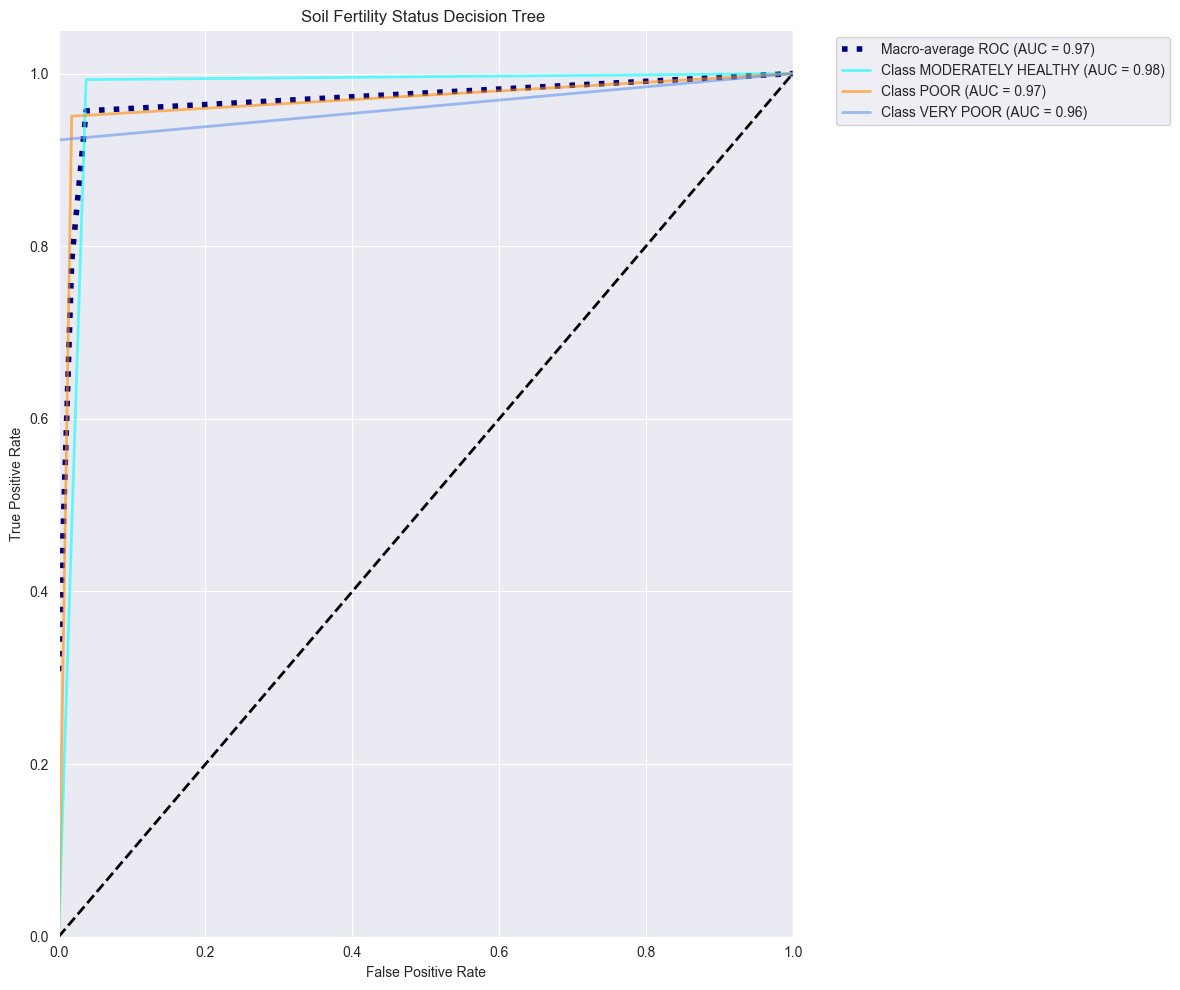

In [95]:
# AUROC Evaluation
evaluate_and_plot_multiclass_roc(dtree, X_test, y_test, class_names, title="Soil Fertility Status Decision Tree ")

In [79]:
# Save the model to a file
joblib.dump(dtree, '../models/Soil_Status_decisionTree_Classifier_model.joblib')

print("Decision Tree Classifier models saved to: models/Soil_Status_decisionTree_Classifier_model")

Decision Tree Classifier models saved to: models/Soil_Status_decisionTree_Classifier_model


Observations:
    - After applying the class_weight = balanced the model showed a 2% decrease in performance ie on Recall and F1-Score

#### 3. Random Forest Classifier

In [ ]:
# Random forest classifier for soil fertility status prediction

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(
    class_weight='balanced_subsample', # used to change the training loss to handle class imbalance
    random_state=142
)

# Fit the model
rf.fit(X_train, y_train)

# Make predictions on test set
y_pred_rf = rf.predict(X_test)

In [81]:
# Model Evaluation for Random Forest
print("\nRandom Forest:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_rf, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_rf, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")


Random Forest:
Accuracy: 0.996
Precision: 0.9977
Recall: 0.9959
F1 Score: 0.9968


In [82]:
print("Classification report:\n", classification_report(y_test, y_pred_rf))

Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       143
           1       1.00      0.99      0.99        81
           2       1.00      1.00      1.00        26

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



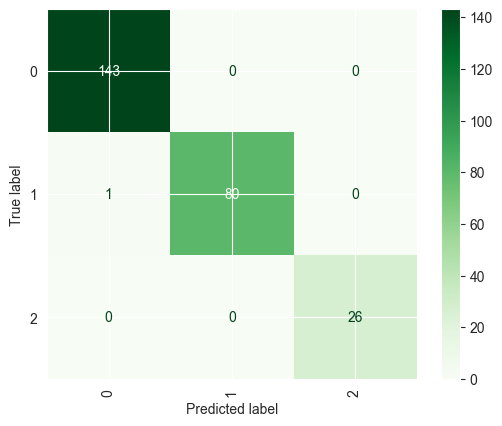

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

# Saving the plot
# plot_path = 'eda_charts/models_evals/random_forest_confusion_matrix.png'
# plt.savefig(plot_path)

plt.show()

Multiclass AUROC Score (Macro Average) for Soil Fertility Status Random Forest Classifier: 1.0000

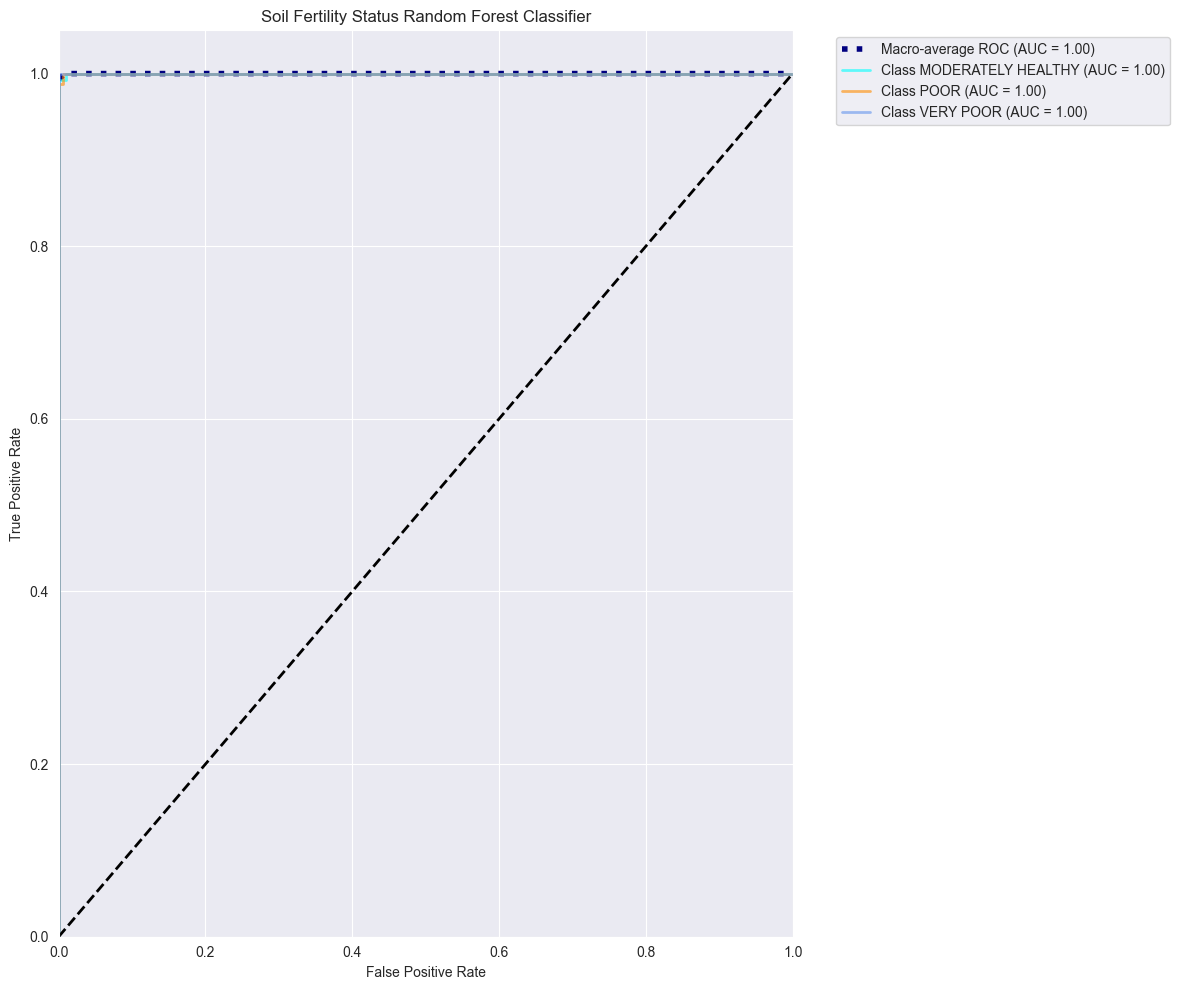

In [ ]:
# Custom function to evaluate and plot AUROC

evaluate_and_plot_multiclass_roc(
    rf, X_test, y_test, class_names, title="Soil Fertility Status Random Forest Classifier"
)

In [85]:
# Save the model to a file
joblib.dump(rf, "../models/Soil_Status_randomForest_Classifier_Model.joblib")

print("Random Forest Classifier saved to: models/Soil_Status_randomForest_Classifier")

Random Forest Classifier saved to: models/Soil_Status_randomForest_Classifier


Observations:
- After Applying the class_weight = balanced_subsample, the model performace did not improve

#### 4. Gradient Boosting Machine

In [88]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [89]:
# xg boost
# Initialise the model
xgb = XGBClassifier(random_state=142)

# Compute weights for every sample in the training set
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Fit the model
xgb.fit(X_train, y_train, sample_weight=sample_weights)

# predict the test set
y_pred_xgb = xgb.predict(X_test)

In [90]:
# Model Evaluation for XGBoost
print("\nGradient Boosting Machine (XGBoost):")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_xgb, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_xgb, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")


Gradient Boosting Machine (XGBoost):
Accuracy: 0.9960
Precision: 0.9959
Recall: 0.9977
F1 Score: 0.9968


In [91]:
print("Classification report:\n", classification_report(y_test, y_pred_xgb))

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       143
           1       0.99      1.00      0.99        81
           2       1.00      1.00      1.00        26

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



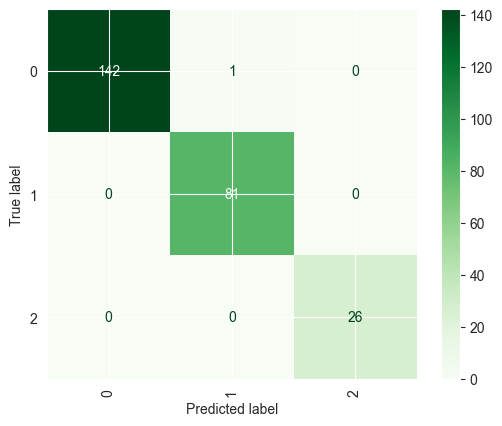

In [92]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb, labels=xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

# Saving the plot
plot_path = '../eda_charts/models_evals/xgboost_confusion_matrix.png'
plt.savefig(plot_path)

plt.show()

Multiclass AUROC Score (Macro Average) for Soil Fertility Status XGBoost: 1.0000


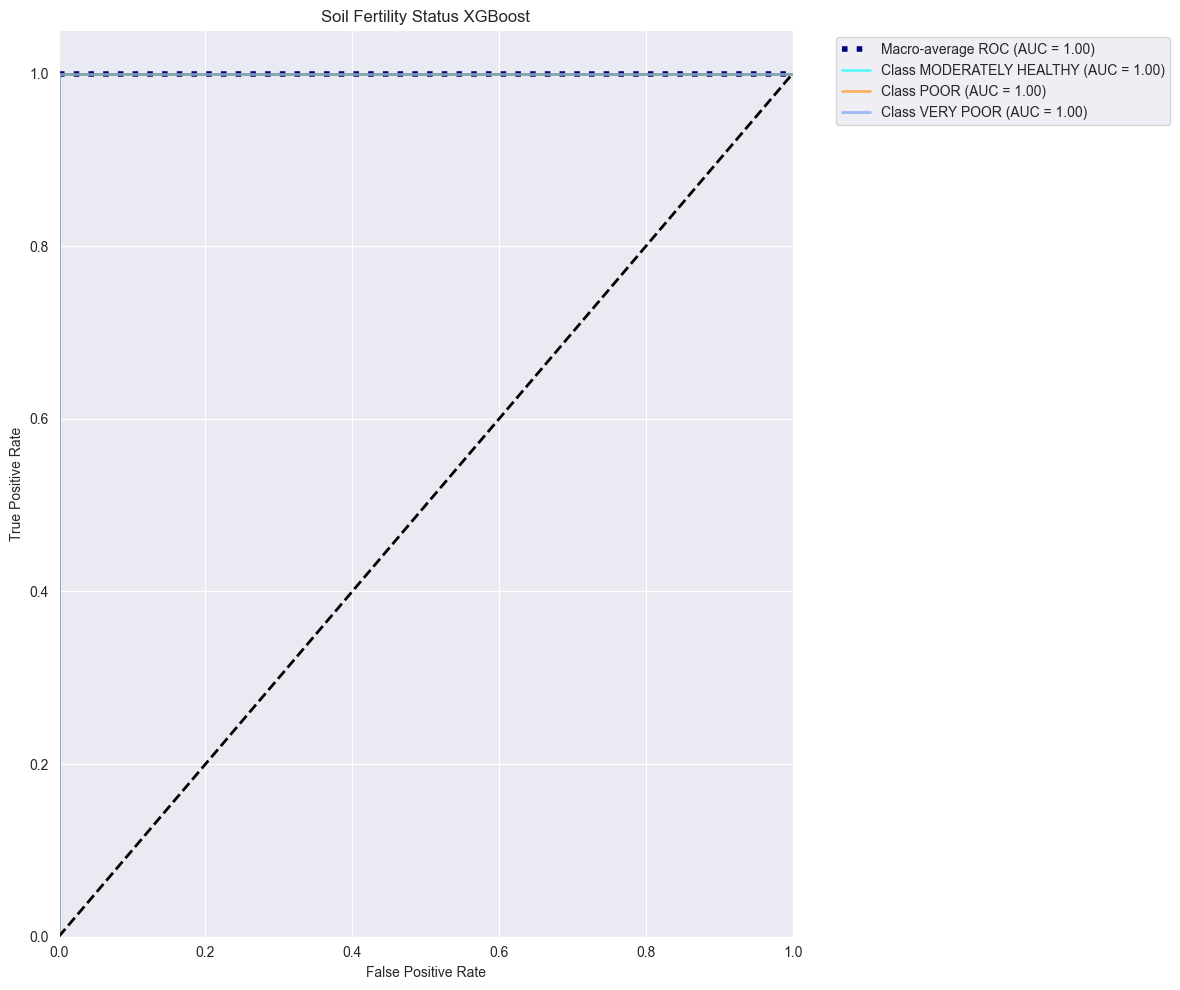

In [97]:
evaluate_and_plot_multiclass_roc(xgb, X_test, y_test, class_names, title="Soil Fertility Status XGBoost")

In [ ]:
# Save the model to a file
joblib.dump(xgb, "../models/Soil_Status_xgb_Model.joblib")

print("Gradient Boosting Classifier saved to: models/Soil_Status_xgb_Classifier")

Gradient Boosting Classifier saved to: models/Soil_Status_xgb_Classifier
